In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

DATA_PATH = "../data/city_lifestyle_dataset.csv"
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [4]:
# numerical features only
X = df.drop(columns=["city_name", "country"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 1.74319203,  0.07125072],
       [ 1.64149334, -0.01498101],
       [ 2.4110457 , -0.32020402],
       [ 1.74815041, -0.75852822],
       [ 3.07870732,  0.97171377]])

In [7]:
var_ratio = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(f"PC1: {var_ratio[0]:.3f}")
print(f"PC2: {var_ratio[1]:.3f}")
print(f"Total (2 components): {var_ratio.sum():.3f}")

Explained variance ratio:
PC1: 0.538
PC2: 0.258
Total (2 components): 0.796


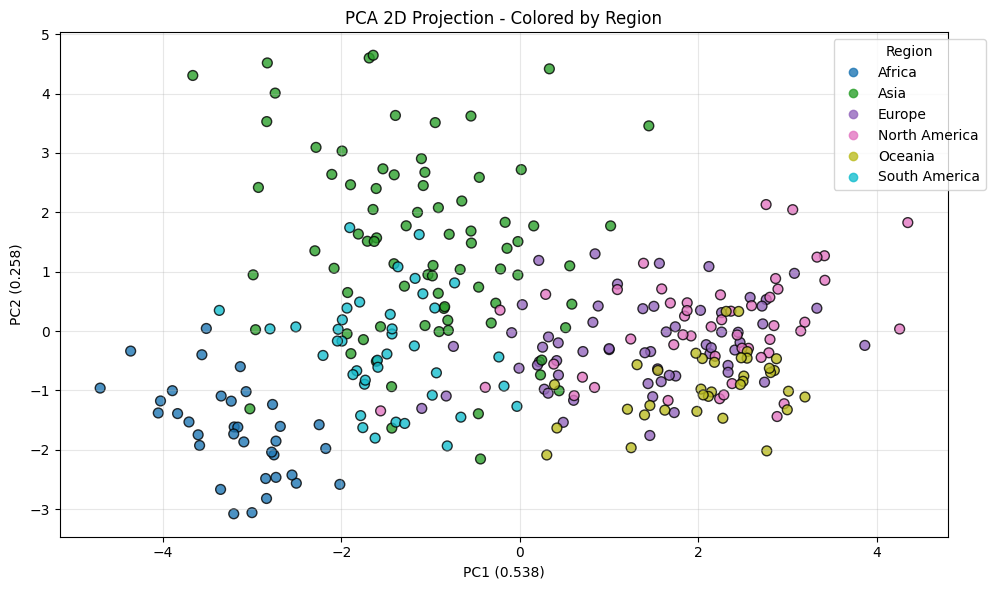

In [9]:
plt.figure(figsize=(10, 6))

countries = df["country"].astype("category")
codes = countries.cat.codes

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=codes,
    cmap="tab10",
    alpha=0.8,
    edgecolor="k",
    s=50
)

plt.xlabel(f"PC1 ({var_ratio[0]:.3f})")
plt.ylabel(f"PC2 ({var_ratio[1]:.3f})")
plt.title("PCA 2D Projection - Colored by Region")

handles, _ = scatter.legend_elements()
plt.legend(handles, countries.cat.categories, title="Region", bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> ### Observation



Les deux premières composantes principales expliquent 79,6 % de la variance totale  (PC1 = 0,538 ; PC2 = 0,258). La projection 2D conserve donc une part importante de l’information contenue dans l’espace initial.

La représentation colorée par région met en évidence une structuration partielle
des données :

- Les régions **Europe**, **North America** et **Oceania** sont majoritairement
  situées dans la zone de **PC1 positive**, avec un recouvrement notable entre elles.

- La région **Africa** apparaît principalement dans la zone de **PC1 négative**,
  avec une dispersion relativement concentrée.

- Les régions **Asia** et **South America** présentent une répartition plus étalée,
  notamment autour de la zone centrale, avec une dispersion visible selon PC2.

La séparation entre régions n’est cependant pas nette : plusieurs zones de chevauchement, en particulier au centre de la projection. Cela indique que certaines villes appartenant à des régions différentes partagent des caractéristiques similaires dans l’espace des variables étudiées.


In [12]:
# Export embeddings 2D (format commun pour le script d'évaluation)
emb_2d = pd.DataFrame({
    "city_name": df["city_name"],
    "country": df["country"],
    "x": X_pca[:, 0],
    "y": X_pca[:, 1],
})

OUTPUT_PATH = os.path.join(OUTPUT_DIR, "pca_emb_2d.csv")
emb_2d.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}, shape={emb_2d.shape}")
emb_2d.head(10)

Saved: ../outputs\pca_emb_2d.csv, shape=(300, 4)


,city_name,country,x,y
0,Old Vista,Europe,1.743192,0.071251
1,Beachport,Europe,1.641493,-0.014981
2,Valleyborough,Europe,2.411046,-0.320204
3,City,Europe,1.748150,-0.758528
4,Falls,Europe,3.078707,0.971714
5,North Falls,Europe,2.262386,-0.017075
6,Hillhaven,Europe,1.457939,-1.760629
7,Gardenton,Europe,1.676221,-0.746590
8,Springsville,Europe,3.330148,0.383688
9,North Ridge,Europe,0.878906,0.420948
